##### About this notebook:

In [ ]:
#-----------------------------------------------------------------------------------------------------------------------------
# Author:             Erick Rico Esparza
# Dates:              Oct 18 - 28, 2025
# Description:        This notebook further explores datasets from Mexico City and NARR files, aiming to prepare the Week 5 presentation.
#-----------------------------------------------------------------------------------------------------------------------------

# Week 5

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy import stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import ttest_ind

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

### Automatic verification (quality control)

In [4]:
BASE = "https://psl.noaa.gov/thredds/dodsC/Datasets/NARR/Dailies/pressure/"
years  = range(2012, 2025)
months = [f"{m:02d}" for m in range(1,13)]

print("🔍 Checking NARR hgt monthly files (2012–2024) via THREDDS/OPeNDAP...\n")

for y in years:
    for m in months:
        url = f"{BASE}hgt.{y}{m}.nc"
        try:
            # netcdf4 backend supports OPeNDAP
            ds = xr.open_dataset(url, engine="netcdf4")
            # selecting level 500 hPa by sel (more robust than fixed index)
            # reading only a couple of points to force minimal access
            h = ds["hgt"].sel(level=500).isel(time=0, y=slice(100,102), x=slice(150,152)).mean().item()
            ok = not (np.isnan(h) or np.isinf(h))
            print(f"{y}-{m}: {'✅ OK' if ok else '⚠️ NaN'} (sample mean={h})")
            ds.close()
        except Exception as e:
            print(f"{y}-{m}: ❌ Error ({str(e)[:80]})")

🔍 Checking NARR hgt monthly files (2012–2024) via THREDDS/OPeNDAP...



c:\Users\DELL\anaconda3\Lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'hgt' has multiple fill values {np.float32(9.96921e+36), np.float32(-9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


2012-01: ✅ OK (sample mean=5806.0625)


c:\Users\DELL\anaconda3\Lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'hgt' has multiple fill values {np.float32(9.96921e+36), np.float32(-9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


2012-02: ✅ OK (sample mean=5659.8173828125)


...

2024-10: ✅ OK (sample mean=5932.01708984375)


c:\Users\DELL\anaconda3\Lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'hgt' has multiple fill values {np.float32(9.96921e+36), np.float32(-9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


2024-11: ✅ OK (sample mean=5699.41650390625)


c:\Users\DELL\anaconda3\Lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'hgt' has multiple fill values {np.float32(9.96921e+36), np.float32(-9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


2024-12: ✅ OK (sample mean=5792.42333984375)


## For H = 500 hPa

### Building the “mini” NetCDFs (500 hPa, 2012–2024, MCMA clipping)

In [3]:
from xarray.coding.variables import SerializationWarning
import warnings

# Silencing the fill values ​​warning
warnings.filterwarnings("ignore", category=SerializationWarning)

BASE = "https://psl.noaa.gov/thredds/dodsC/Datasets/NARR/Dailies/pressure/"
years  = range(2012, 2025)               # 2012–2024
months = [f"{m:02d}" for m in range(1,13)]
twin   = (pd.Timestamp("2012-01-01"), pd.Timestamp("2024-12-31"))

# --- 1) Detecting bbox at indices (y,x) with a sample file ---
sample = xr.open_dataset(f"{BASE}hgt.201201.nc", engine="netcdf4")
lat2d, lon2d = sample["lat"], sample["lon"]
LON_MIN, LON_MAX = -120, -85
LAT_MIN, LAT_MAX = 10, 35

mask = (lon2d>=LON_MIN) & (lon2d<=LON_MAX) & (lat2d>=LAT_MIN) & (lat2d<=LAT_MAX)
yy, xx = np.where(mask)
y0, y1 = yy.min(), yy.max()
x0, x1 = xx.min(), xx.max()
sample.close()

def build_mini(var_folder_name: str, varname: str, out_path: str):
    """
    Opens month by month (without parallelism), subselects:
      - level = 500 hPa
      - bbox by indices y,x
      - time window 2012–2024
    Concatenates by 'time' and saves files compressed.
    """
    pieces = []
    for y in years:
        for m in months:
            url = f"{BASE}{var_folder_name}.{y}{m}.nc"
            try:
                ds = xr.open_dataset(url, engine="netcdf4", decode_cf=True)
                da = ds[varname]

                # Time filter by month and by global twin window
                # (this helps if the server fails with out-of-bounds times)
                da = da.sel(time=slice(twin[0], twin[1]))

                # Level 500 hPa (by label, not by index)
                if "level" in da.dims:
                    da = da.sel(level=500)

                # Spatial cropping using detected indices
                da = da.isel(y=slice(y0, y1+1), x=slice(x0, x1+1))

                # In some months it could come empty → skip
                if da.sizes.get("time", 0) == 0:
                    ds.close()
                    continue

                # Modest chunks to avoid loading RAM
                da = da.chunk({"time": min(da.sizes["time"], 31)})

                pieces.append(da)
                ds.close()
            except Exception as e:
                print(f"Skip {y}-{m} ({varname}): {str(e)[:80]}")
                continue

    if not pieces:
        raise RuntimeError(f"Nothing was gathered for {varname}.")

    # Concatenates by time; sometimes there are duplicate auxiliary coords.
    # Explicitly set coords="minimal" to avoid the conflict between coords and compat.
    out = xr.concat(pieces, dim="time", compat="override", join="override", coords="minimal")

    # Ensures type and compression
    comp = dict(zlib=True, complevel=3)
    out.to_netcdf(out_path, encoding={varname: comp})
    print(f"Saved: {out_path} ({out.sizes['time']} days)")

# --- 2) Build HGT, U, V ---
build_mini("hgt",  "hgt",  "hgt500_mex_2012_2024.nc")
build_mini("uwnd", "uwnd", "uwnd500_mex_2012_2024.nc")
build_mini("vwnd", "vwnd", "vwnd500_mex_2012_2024.nc")

Saved: hgt500_mex_2012_2024.nc (4749 days)
Saved: uwnd500_mex_2012_2024.nc (4749 days)
Saved: vwnd500_mex_2012_2024.nc (4749 days)


### Reading the already cleaned CSV, extract the average city and event dates (monthly p90)

#### Quick verification

In [5]:
# === 1) Loading old clean CSV and making sure the 'DATE' column is correct ===
path = "cleaned_cdmx_air_2012-2024.csv"

# Loading without parse_dates (for full control) and stripping whitespace from headers
df = pd.read_csv(path)
df.columns = [c.strip().upper() for c in df.columns]

# Normalizing the name of the date column in case 'DATE' or similar appears
if "DATE" not in df.columns:
    # Trying to detect a candidate column
    candidates = [c for c in df.columns if c in ("FECHA","Date","date")]
    if candidates:
        df = df.rename(columns={candidates[0]:"DATE"})
    else:
        raise ValueError("I can't find a date column. Make sure you have 'DATE' in your CSV.")

# Stripping whitespace and converting to datetime (coerce -> NaT in problematic rows)
df["DATE"] = pd.to_datetime(df["DATE"].astype(str).str.strip(), errors="coerce")

# Quick diagnosis
print(">>> Quick diagnosis of DATE")
print("dtype:", df["DATE"].dtype)
print("NaT in DATE:", df["DATE"].isna().sum())
if df["DATE"].isna().any():
    print("First rows with DATE NaT:")
    print(df[df["DATE"].isna()].head(5))

# Dropping rows without valid date
df = df.dropna(subset=["DATE"])

# Verifying type of 'DATE' column
print("\n>>> Verifying 'DATE' column type after cleaning:")
print("dtype:", df["DATE"].dtype)
print(df.info())

# === 2) Ensuring numeric types in pollutants ===
# Estimating which columns are pollutants
possible_cols = ["NO2","O3","PM10","PM2.5","PM2_5","SO2","CO"]
present = [c for c in possible_cols if c in df.columns]
if not present:
    raise ValueError("I can't find any columns of pollutants (NO2, O3, PM10, PM2.5/PM2_5, SO2, CO).")

# If PM2_5 exists but not PM2.5 (or vice versa), we unify it to 'PM2.5'
if "PM2.5" not in present and "PM2_5" in present:
    df = df.rename(columns={"PM2_5":"PM2.5"})
    present = [("PM2.5" if c=="PM2_5" else c) for c in present]

# Convert to numeric (forcing NaN when there are strange strings)
for c in present:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Diagnosis of non-zero by contaminant
print("\n>>> Non-zero counts by contaminant:")
print(df[present].notna().sum())

>>> Quick diagnosis of DATE
dtype: datetime64[ns]
NaT in DATE: 0

>>> Verifying 'DATE' column type after cleaning:
dtype: datetime64[ns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27399 entries, 0 to 27398
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   DATE     27399 non-null  datetime64[ns]
 1   STATION  27399 non-null  object        
 2   NO2      27399 non-null  int64         
 3   O3       27399 non-null  int64         
 4   PM10     27399 non-null  int64         
 5   PM2.5    27399 non-null  int64         
 6   SO2      27399 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 1.5+ MB
None

>>> Non-zero counts by contaminant:
NO2      27399
O3       27399
PM10     27399
PM2.5    27399
SO2      27399
dtype: int64


In [6]:
# === 3) Exact time cut to 2012–2024 (for safety) ===
df = df[(df["DATE"]>=pd.Timestamp("2012-01-01")) & (df["DATE"]<=pd.Timestamp("2024-12-31"))]

print("\n>>> Final dataframe info:")
print(df.info())


>>> Final dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27399 entries, 0 to 27398
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   DATE     27399 non-null  datetime64[ns]
 1   STATION  27399 non-null  object        
 2   NO2      27399 non-null  int64         
 3   O3       27399 non-null  int64         
 4   PM10     27399 non-null  int64         
 5   PM2.5    27399 non-null  int64         
 6   SO2      27399 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 1.5+ MB
None


#### Building the city average per day

In [7]:
# === 4) Average CITY per day (average across available stations) ===
city = (df.drop(columns=["STATION"])
            .groupby("DATE", as_index=True)
            .mean(numeric_only=True))

# Sorting by date and ensure daily frequency
city = city.sort_index()

print("\n>>> Time range of city:")
print(city.index.min(), "→", city.index.max())
print("Rows (days):", len(city))

# Cache saving
city.to_csv("cdmx_citymean_daily_2012_2024.csv")


>>> Time range of city:
2012-01-01 00:00:00 → 2024-12-31 00:00:00
Rows (days): 4555


#### Generating the monthly P90 event dates

In [8]:
# === 5) Monthly p90 event dates by pollutant (robust to seasonality) ===
def top10_by_month(series: pd.Series) -> pd.DatetimeIndex:
    ev = []
    for _, s in series.groupby(series.index.to_period('M')):
        if len(s) == 0: 
            continue
        thr = s.quantile(0.90)
        ev += s[s >= thr].index.tolist()
    return pd.DatetimeIndex(sorted(set(ev)))

pollutants = ["PM2.5","PM10","O3","NO2","SO2"]
pollutants = [p for p in pollutants if p in city.columns]

events = {p: top10_by_month(city[p].dropna()) for p in pollutants}

print("\n>>> Event day count by pollutant (monthly p90):")
for p in pollutants:
    print(f"{p:5s}: {len(events[p])} days")

# Saving event dates to CSV for extra inspection
for p in pollutants:
    pd.Series(events[p], name="DATE").to_csv(f"events_{p}_p90_by_month_2012_2024.csv", index=False)


>>> Event day count by pollutant (monthly p90):
PM2.5: 549 days
PM10 : 542 days
O3   : 548 days
NO2  : 545 days
SO2  : 549 days


#### Composites

c:\Users\DELL\anaconda3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\DELL\anaconda3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


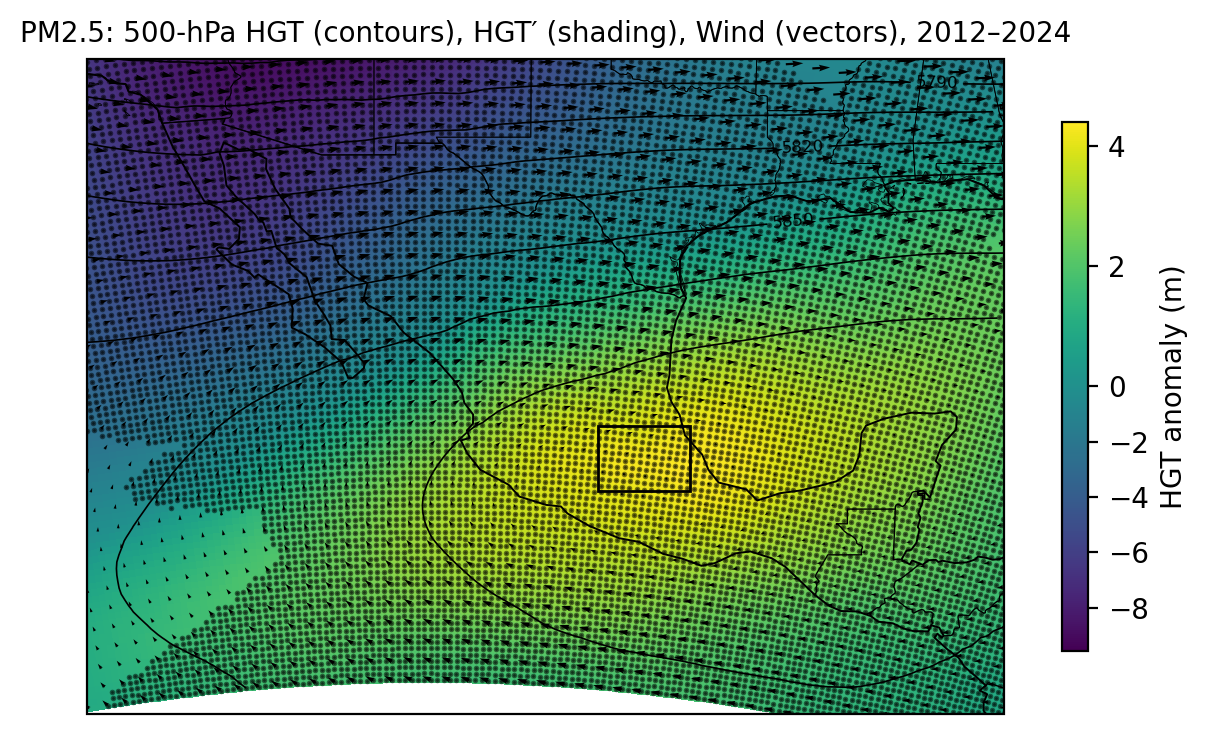

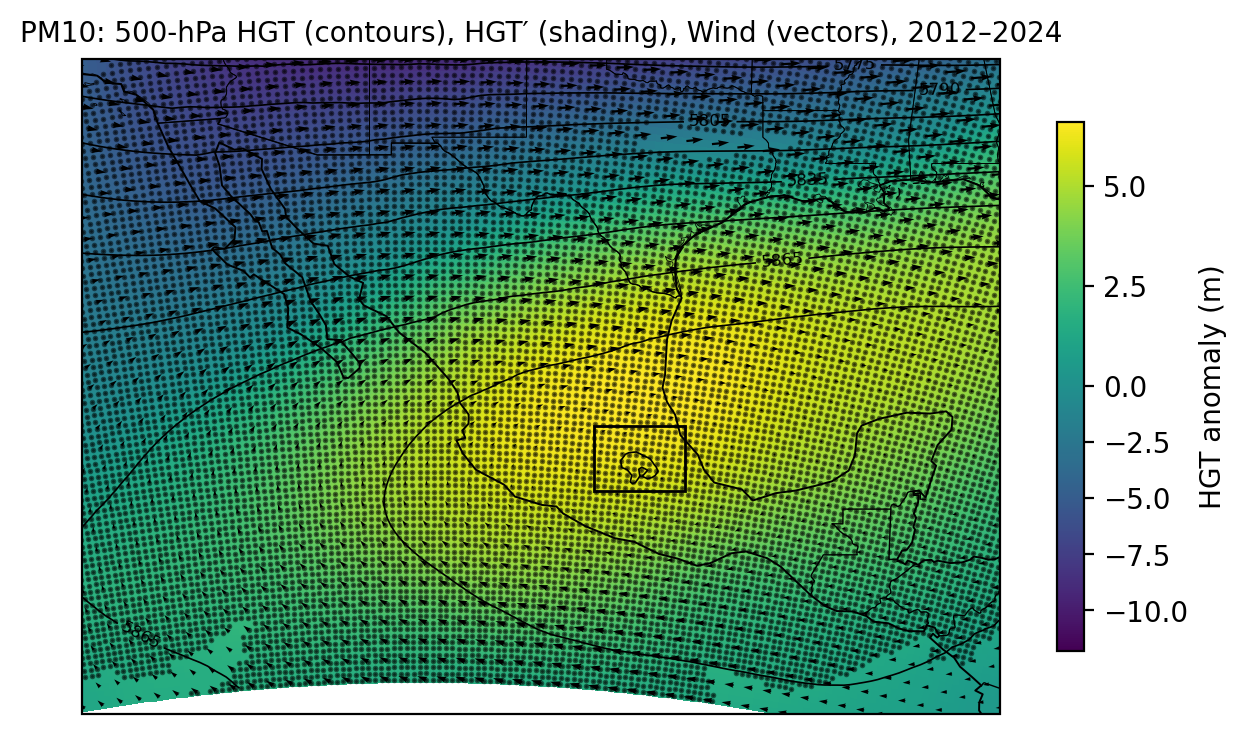

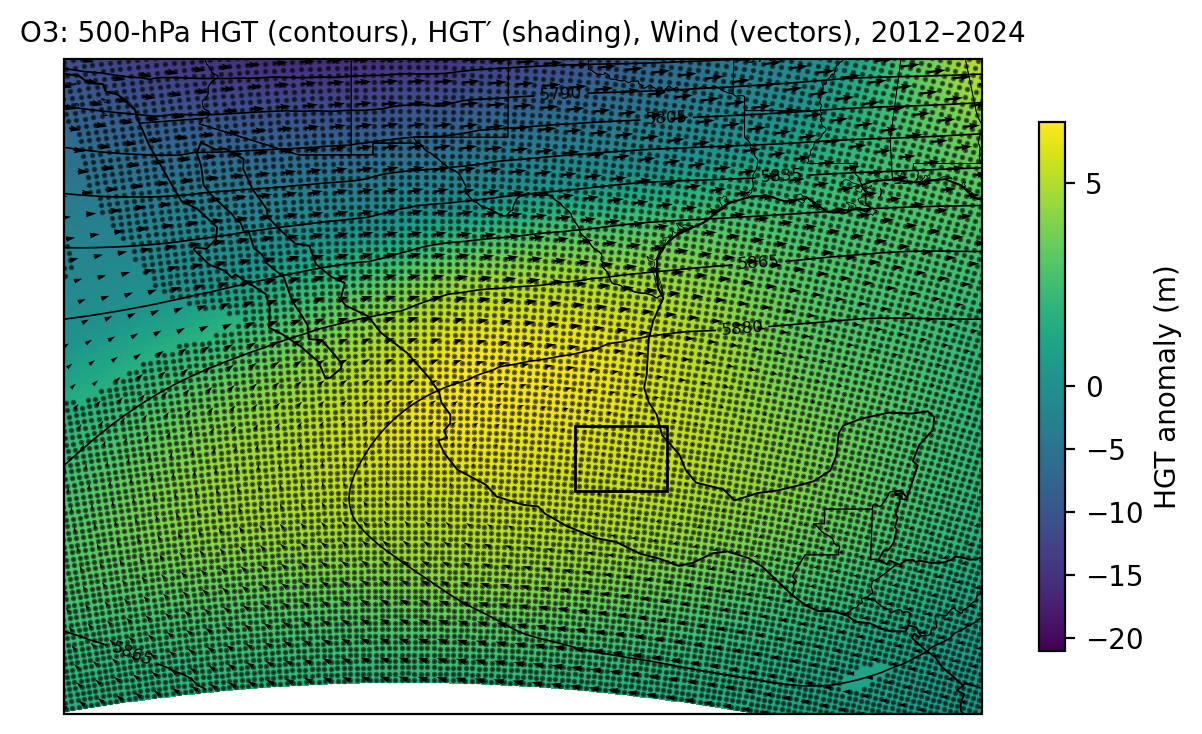

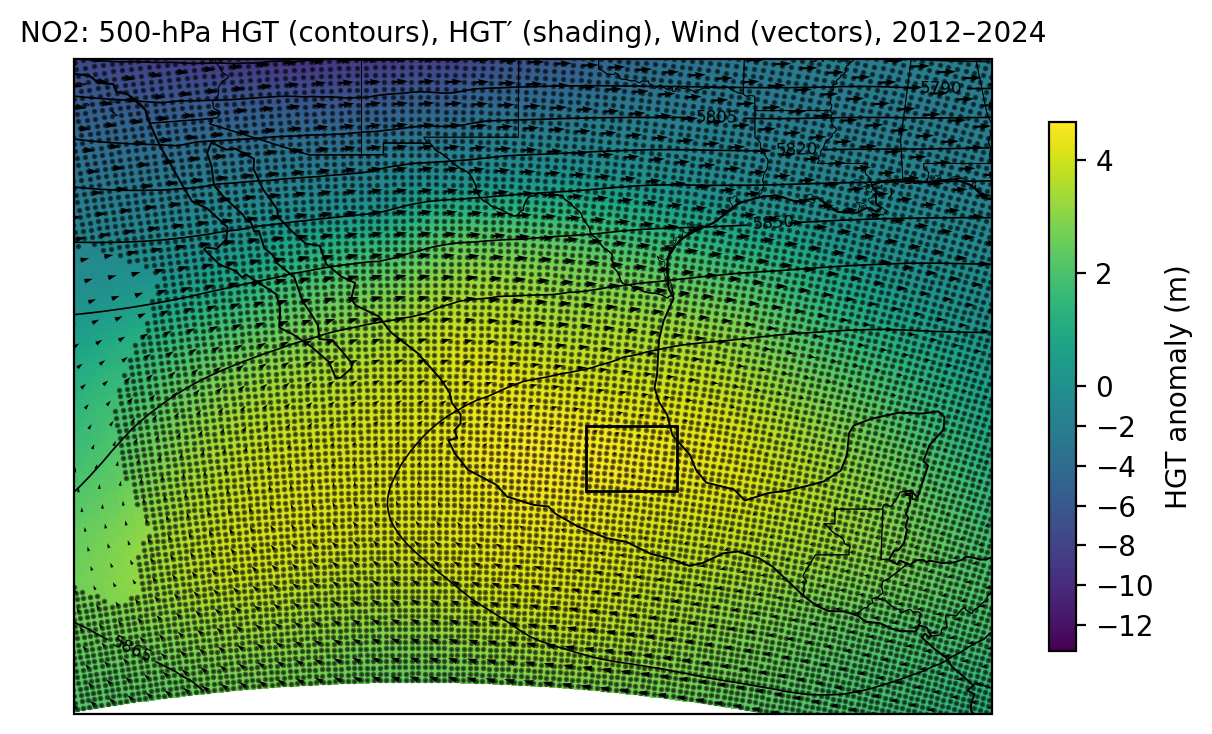

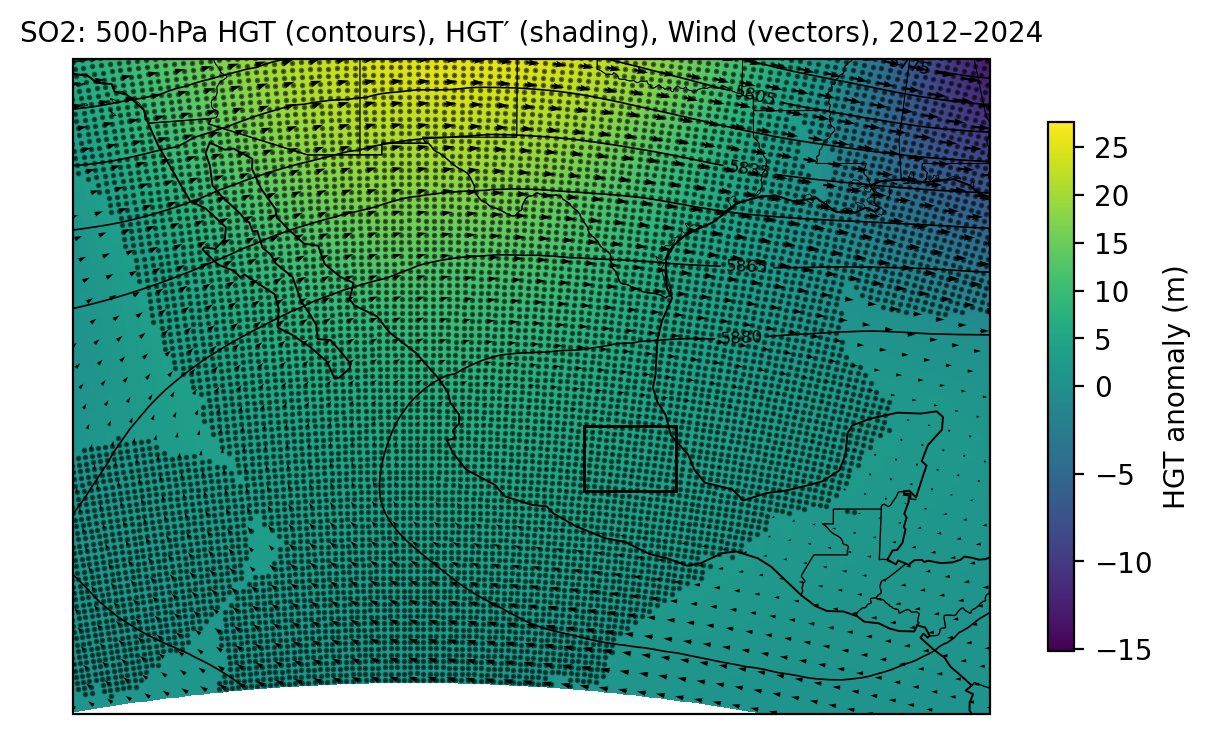

In [9]:
# 1) Defining the map domain (MCMA)
LON_MIN, LON_MAX = -120, -85
LAT_MIN, LAT_MAX = 10, 35

# 2) Loading the mini NetCDF
H = xr.open_dataset("hgt500_mex_2012_2024.nc")["hgt"]  # [time, y, x]
U = xr.open_dataset("uwnd500_mex_2012_2024.nc")["uwnd"]
V = xr.open_dataset("vwnd500_mex_2012_2024.nc")["vwnd"]

# 3) Daily climatology by DOY (smoothed) and HGT′ anomalies
H = H.assign_coords(time=pd.to_datetime(H.time.values))
H_noleap = H.sel(time=~((H.time.dt.month==2) & (H.time.dt.day==29)))
clim = H_noleap.groupby("time.dayofyear").mean("time")
clim = clim.rolling(dayofyear=31, center=True, min_periods=1).mean()  # softens
Hprime = xr.apply_ufunc(
    lambda data, doy_clim, doy: data - doy_clim[doy - 1],
    H, clim, H["time"].dt.dayofyear,
    input_core_dims=[[], ["dayofyear"], []],
    vectorize=True
)

# 4) Functions for composite and pixelwise t-test
def composite(ds, dates):
    dates = pd.DatetimeIndex(dates)
    dates = dates[(dates>=pd.to_datetime(H.time.values.min())) & (dates<=pd.to_datetime(H.time.values.max()))]
    return ds.sel(time=dates).mean("time", skipna=True)

def ttest_anom(event_dates):
    # event: H′ on dates; control: H′ on other days in the same month
    evt = Hprime.sel(time=Hprime.time.isin(event_dates))
    months_evt = pd.DatetimeIndex(evt.time.values).month
    p_layers = []
    for m in np.unique(months_evt):
        A = evt.sel(time=evt.time.dt.month==m)                     # events
        B = Hprime.sel(time=(~Hprime.time.isin(A.time)) & (Hprime.time.dt.month==m))  # no-events, same month
        t, p = stats.ttest_ind(A, B, axis=0, equal_var=False, nan_policy="omit")
        p_layers.append(xr.DataArray(p, coords=A.isel(time=0).coords, dims=A.isel(time=0).dims))
    p_all = xr.concat(p_layers, dim="month").min("month")  # conservative
    return (p_all < 0.05)

# 5) Plot (HGT contour, H′ shading, U,V vectors, stippling, MCMA rectangle)
def plot_map(H_mean, H_anom, U_mean, V_mean, pmask, title, fname=None):
    proj = ccrs.LambertConformal(central_longitude=-107, central_latitude=50)  # NARR mesh
    data_crs = proj  # NARR is already in Lambert; cartopy will use its grid.
    fig = plt.figure(figsize=(7.4, 4.4), dpi=200)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='110m', linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)

    # we need 2D lat/lon for pcolormesh/contour/quiver
    # let's take them from the original dataset (coordinates attached)
    # H_mean/H_anom preserve lat/lon in coords (should come as DataArrays with auxiliary x,y and lat/lon)
    lat2d = H_mean["lat"].values
    lon2d = H_mean["lon"].values

    # shading anomalies
    norm = TwoSlopeNorm(vcenter=0.0)
    sh = ax.pcolormesh(lon2d, lat2d, H_anom, transform=ccrs.PlateCarree(), shading="auto", norm=norm)
    cb = plt.colorbar(sh, ax=ax, shrink=0.78, label="HGT anomaly (m)")

    # contours of mean HGT
    cs = ax.contour(lon2d, lat2d, H_mean, transform=ccrs.PlateCarree(), levels=12, colors='k', linewidths=0.6)
    ax.clabel(cs, inline=True, fmt="%d", fontsize=6)

    # wind vectors (subsampling)
    step = 3
    q = ax.quiver(lon2d[::step, ::step], lat2d[::step, ::step],
                  U_mean.values[::step, ::step], V_mean.values[::step, ::step],
                  transform=ccrs.PlateCarree(), scale=700)
    ax.quiverkey(q, 0.88, -0.05, 8, "8 m/s", labelpos="E")

    # stippling p<0.05
    yy, xx = np.where(pmask.values)
    ax.scatter(lon2d[yy, xx], lat2d[yy, xx], s=1, c='k', alpha=0.5, transform=ccrs.PlateCarree())

    # MCMA box
    rect = mpatches.Rectangle(xy=(-100.5, 18.5), width=3.5, height=2.5,
                              linewidth=1.0, fill=False, edgecolor='k', transform=ccrs.PlateCarree())
    ax.add_patch(rect)

    ax.set_title(title, fontsize=10)
    if fname:
        plt.savefig(fname, bbox_inches="tight", dpi=300)
    plt.show()

# 6) Loop for each pollutant → composites/t-test/plot
pollutants = ["PM2.5", "PM10", "O3", "NO2", "SO2"]
for pol in pollutants:
    dates = events[pol]
    Hm   = composite(H, dates)
    Hp   = composite(Hprime, dates)
    Um   = composite(U, dates)
    Vm   = composite(V, dates)
    Pmk  = ttest_anom(dates)

    plot_map(Hm, Hp, Um, Vm, Pmk,
             title=f"{pol}: 500-hPa HGT (contours), HGT′ (shading), Wind (vectors), 2012–2024",
             fname=f"map_{pol}_500hPa_2012-2024.png")


## Repeating the process for H = 850 hPa

### Building the NetCDFs

In [12]:
from xarray.coding.variables import SerializationWarning
import warnings

# Silencing the fill values ​​warning
warnings.filterwarnings("ignore", category=SerializationWarning)

BASE = "https://psl.noaa.gov/thredds/dodsC/Datasets/NARR/Dailies/pressure/"
years  = range(2012, 2025)               # 2012–2024
months = [f"{m:02d}" for m in range(1,13)]
twin   = (pd.Timestamp("2012-01-01"), pd.Timestamp("2024-12-31"))

# --- 1) Detecting bbox at indices (y,x) with a sample file ---
sample = xr.open_dataset(f"{BASE}hgt.201201.nc", engine="netcdf4")
lat2d, lon2d = sample["lat"], sample["lon"]
LON_MIN, LON_MAX = -120, -85
LAT_MIN, LAT_MAX = 10, 35

mask = (lon2d>=LON_MIN) & (lon2d<=LON_MAX) & (lat2d>=LAT_MIN) & (lat2d<=LAT_MAX)
yy, xx = np.where(mask)
y0, y1 = yy.min(), yy.max()
x0, x1 = xx.min(), xx.max()
sample.close()

def build_mini(var_folder_name: str, varname: str, out_path: str):
    """
    Opens month by month (without parallelism), subselects:
      - level = 850 hPa
      - bbox by indices y,x
      - time window 2012–2024
    Concatenates by 'time' and saves files compressed.
    """
    pieces = []
    for y in years:
        for m in months:
            url = f"{BASE}{var_folder_name}.{y}{m}.nc"
            try:
                ds = xr.open_dataset(url, engine="netcdf4", decode_cf=True)
                da = ds[varname]

                # Time filter by month and by global twin window
                # (this helps if the server fails with out-of-bounds times)
                da = da.sel(time=slice(twin[0], twin[1]))

                # Level 850 hPa (by label, not by index)
                if "level" in da.dims:
                    da = da.sel(level=850)

                # Spatial cropping using detected indices
                da = da.isel(y=slice(y0, y1+1), x=slice(x0, x1+1))

                # In some months it could come empty → skip
                if da.sizes.get("time", 0) == 0:
                    ds.close()
                    continue

                # Modest chunks to avoid loading RAM
                da = da.chunk({"time": min(da.sizes["time"], 31)})

                pieces.append(da)
                ds.close()
            except Exception as e:
                print(f"Skip {y}-{m} ({varname}): {str(e)[:80]}")
                continue

    if not pieces:
        raise RuntimeError(f"Nothing was gathered for {varname}.")

    # Concatenates by time; sometimes there are duplicate auxiliary coords.
    # Explicitly set coords="minimal" to avoid the conflict between coords and compat.
    out = xr.concat(pieces, dim="time", compat="override", join="override", coords="minimal")

    # Ensures type and compression
    comp = dict(zlib=True, complevel=3)
    out.to_netcdf(out_path, encoding={varname: comp})
    print(f"Saved: {out_path} ({out.sizes['time']} days)")

# --- 2) Build HGT, U, V ---
build_mini("hgt",  "hgt",  "hgt850_mex_2012_2024.nc")
build_mini("uwnd", "uwnd", "uwnd850_mex_2012_2024.nc")
build_mini("vwnd", "vwnd", "vwnd850_mex_2012_2024.nc")

Saved: hgt850_mex_2012_2024.nc (4749 days)
Saved: uwnd850_mex_2012_2024.nc (4749 days)
Saved: vwnd850_mex_2012_2024.nc (4749 days)


Using the `events` dictionary built for 500 hPa.

### Bulding the maps

Plotting PM2.5 ...


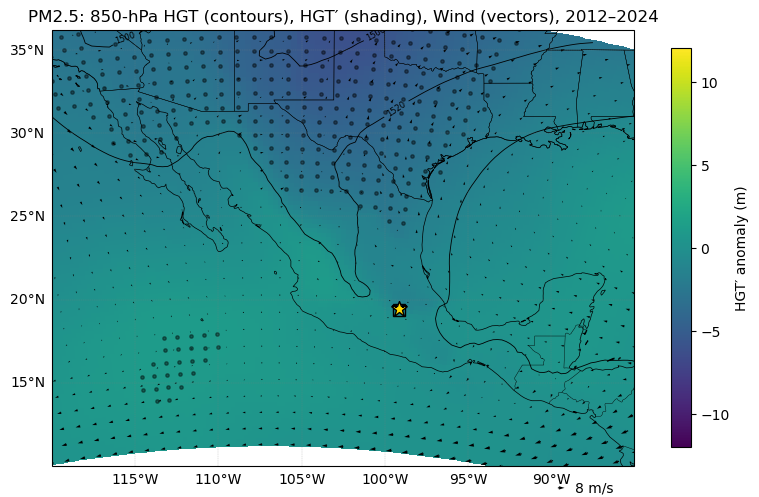

Plotting PM10 ...


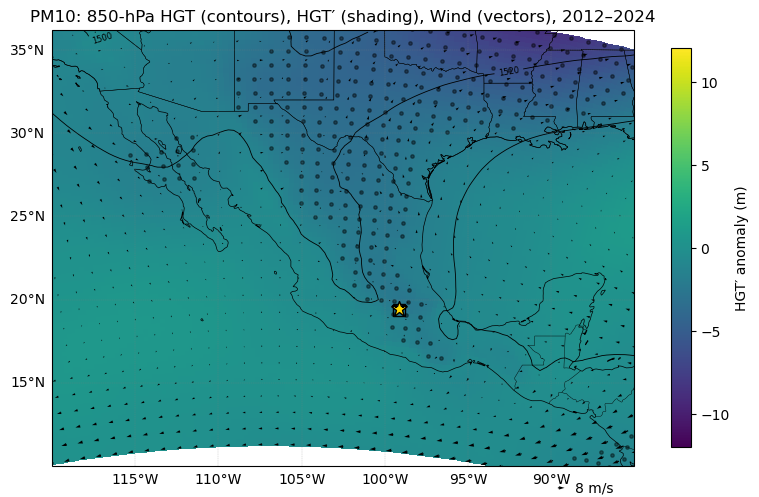

Plotting O3 ...


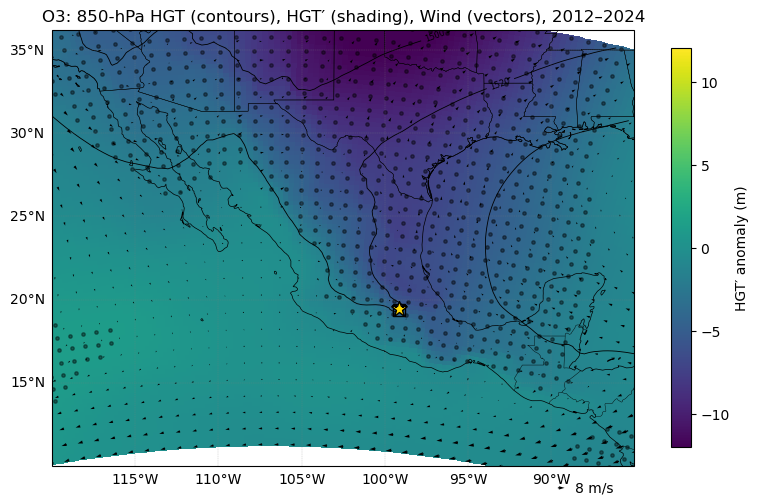

Plotting NO2 ...


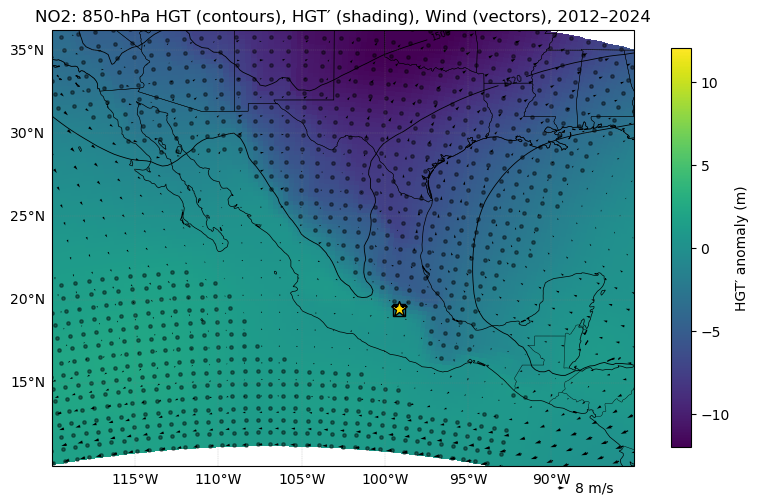

Plotting SO2 ...


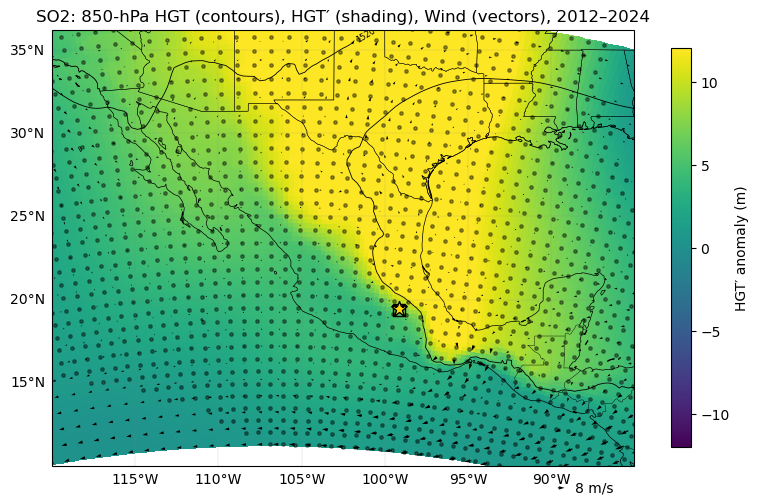

In [ ]:
# === C-850hPa Composite Maps ===

# -----------------------------
# CONFIGURATION
# -----------------------------
pollutants = ["PM2.5", "PM10", "O3", "NO2", "SO2"]
level = 850
LON_MIN, LON_MAX = -120, -85
LAT_MIN, LAT_MAX = 10, 35
LON_CDMX, LAT_CDMX = -99.13, 19.43  # for the star
MCMA_BOX = (-99.5, 19.0, -98.8, 19.75)
vmin, vmax = -12, 12  # fixed range for comparability

# -----------------------------
# LOAD DATA
# -----------------------------
hgt = xr.open_dataset("hgt850_mex_2012_2024.nc")["hgt"]
uwnd = xr.open_dataset("uwnd850_mex_2012_2024.nc")["uwnd"]
vwnd = xr.open_dataset("vwnd850_mex_2012_2024.nc")["vwnd"]

lon2d = hgt["lon"].values  # 2-D (y,x)
lat2d = hgt["lat"].values

# -----------------------------
# PLOTTING FUNCTION
# -----------------------------
def plot_composite_850(pollutant):
    print(f"Plotting {pollutant} ...")
    days_event = events[pollutant]  # reusing the dictionary from 500 hPa section

    # Means
    H_event = hgt.sel(time=days_event).mean("time")
    H_mean = hgt.mean("time")
    H_anom = H_event - H_mean

    # Mean wind during events
    U_mean = uwnd.sel(time=days_event).mean("time")
    V_mean = vwnd.sel(time=days_event).mean("time")

    # Significance test
    H_event_vals = hgt.sel(time=days_event)
    H_non_event = hgt.drop_sel(time=days_event)
    tstat, pval = ttest_ind(H_event_vals, H_non_event, axis=0, equal_var=False, nan_policy="omit")
    sig = xr.DataArray(pval < 0.05, coords=H_mean.coords)

    # Plot
    fig = plt.figure(figsize=(8,6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
    ax.add_feature(cfeature.COASTLINE, lw=0.5)
    ax.add_feature(cfeature.BORDERS, lw=0.3)
    ax.add_feature(cfeature.STATES.with_scale('50m'), lw=0.3)

    # HGT′ anomaly
    pcm = ax.pcolormesh(lon2d, lat2d, H_anom, cmap="viridis", vmin=vmin, vmax=vmax,
                        transform=ccrs.PlateCarree(), shading="auto")

    # Contours of HGT (mean field)
    cs = ax.contour(lon2d, lat2d, H_event, levels=np.arange(1400, 1650, 20),
                    colors='k', linewidths=0.6, transform=ccrs.PlateCarree())
    ax.clabel(cs, fmt='%d', fontsize=6)

    # Quiver arrows
    step = 4
    q = ax.quiver(lon2d[::step, ::step], lat2d[::step, ::step],
                  U_mean.values[::step, ::step], V_mean.values[::step, ::step],
                  transform=ccrs.PlateCarree(), scale=700, width=0.002)
    ax.quiverkey(q, 0.88, -0.05, 8, "8 m/s", labelpos="E")

    # Stippling (p<0.05)
    y, x = np.where(sig[::3, ::3])  # subsampling
    ax.scatter(lon2d[::3, ::3][y, x], lat2d[::3, ::3][y, x], s=6, c='k', alpha=0.4,
               transform=ccrs.PlateCarree())

    # MCMA box
    rect = mpatches.Rectangle(xy=(MCMA_BOX[0], MCMA_BOX[1]),
                              width=MCMA_BOX[2]-MCMA_BOX[0],
                              height=MCMA_BOX[3]-MCMA_BOX[1],
                              linewidth=1, edgecolor='k', facecolor='none',
                              transform=ccrs.PlateCarree())
    ax.add_patch(rect)

    # CDMX star
    ax.plot(LON_CDMX, LAT_CDMX, marker='*', color='gold', markersize=12,
            markeredgecolor='k', transform=ccrs.PlateCarree())

    # Grid
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray',
                      alpha=0.5, linestyle='--')
    gl.right_labels = gl.top_labels = False

    # Colorbar and title
    cbar = plt.colorbar(pcm, ax=ax, shrink=0.7, label="HGT′ anomaly (m)")
    ax.set_title(f"{pollutant}: 850-hPa HGT (contours), HGT′ (shading), Wind (vectors), 2012–2024")

    plt.tight_layout()
    plt.savefig(f"composite_850_{pollutant}.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run for each pollutant
for p in pollutants:
    plot_composite_850(p)

#### Multipanel layout (2x3, 5 panels, common colorbar)

C:\Users\DELL\AppData\Local\Temp\ipykernel_17768\4009795686.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.9,1])


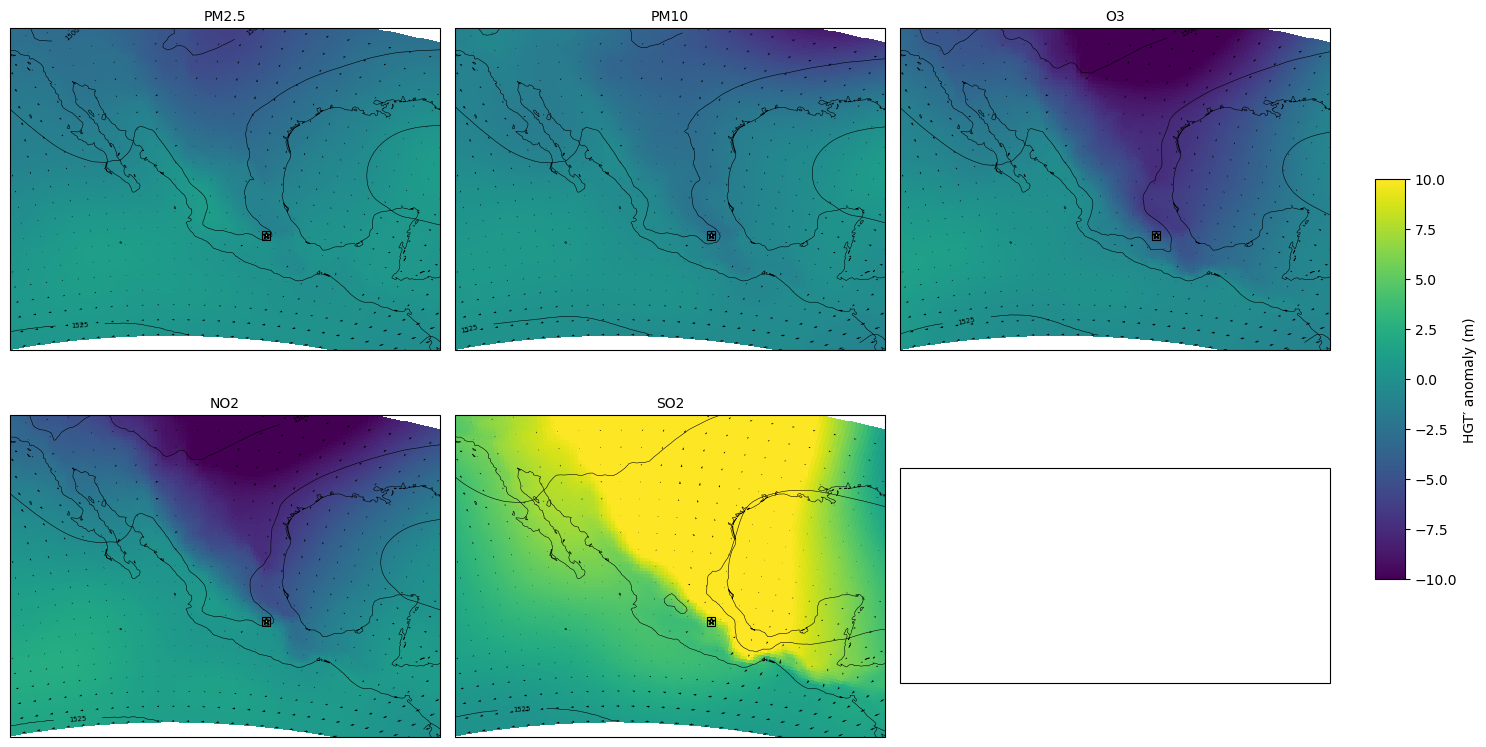

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15,8),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

vmin, vmax = -10, 10  # fixed range for comparability

for i, p in enumerate(pollutants):
    ax = axes[i]
    days_event = events[p]
    H_event = hgt.sel(time=days_event).mean("time")
    H_mean  = hgt.mean("time")
    H_anom  = H_event - H_mean
    U_mean  = uwnd.sel(time=days_event).mean("time")
    V_mean  = vwnd.sel(time=days_event).mean("time")

    pcm = ax.pcolormesh(lon2d, lat2d, H_anom, cmap="viridis",
                        vmin=vmin, vmax=vmax, shading="auto",
                        transform=ccrs.PlateCarree())

    cs = ax.contour(lon2d, lat2d, H_event,
                    levels=np.arange(1400, 1651, 25),
                    colors='k', linewidths=0.4, transform=ccrs.PlateCarree())
    ax.clabel(cs, fmt='%d', fontsize=5)

    ax.quiver(lon2d[::5, ::5], lat2d[::5, ::5],
              U_mean.values[::5, ::5], V_mean.values[::5, ::5],
              transform=ccrs.PlateCarree(), scale=750, width=0.0015)

    # Box + star (visual consistency)
    rect = mpatches.Rectangle((MCMA_BOX[0], MCMA_BOX[1]),
                              MCMA_BOX[2]-MCMA_BOX[0], MCMA_BOX[3]-MCMA_BOX[1],
                              linewidth=0.8, edgecolor='k', facecolor='none',
                              transform=ccrs.PlateCarree())
    ax.add_patch(rect)
    ax.plot(LON_CDMX, LAT_CDMX, marker='*', color='gold',
            markersize=5, markeredgecolor='k', transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, lw=0.4)
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
    ax.set_title(p, fontsize=10)

# Common colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
fig.colorbar(pcm, cax=cbar_ax, label="HGT′ anomaly (m)")
plt.tight_layout(rect=[0,0,0.9,1])
plt.savefig("layout_850_all_pollutants.png", dpi=300, bbox_inches='tight')
plt.show()


#### p90 histograms

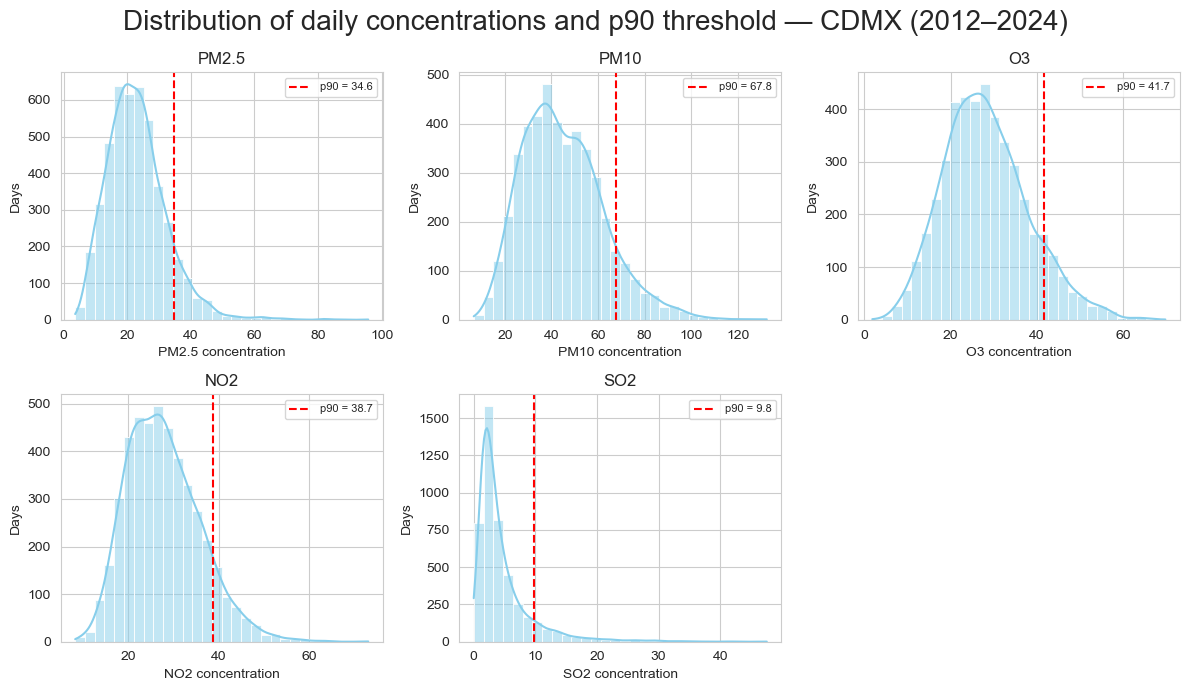

In [20]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(12,7))
axes = axes.flatten()

for i, p in enumerate(pollutants):
    ax = axes[i]
    data = city[p].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax, color="skyblue")
    p90 = np.percentile(data, 90)
    ax.axvline(p90, color="red", linestyle="--", lw=1.5, label=f"p90 = {p90:.1f}")
    ax.set_title(p)
    ax.legend(fontsize=8)
    ax.set_xlabel(f"{p} concentration")
    ax.set_ylabel("Days")

# deactivate the sixth empty subplot
axes[-1].axis('off')

# general title for the multipanel
fig.suptitle("Distribution of daily concentrations and p90 threshold — CDMX (2012–2024)",
             y=0.98, fontsize=20)

plt.tight_layout()
plt.savefig("histogram_p90_all.png", dpi=300, bbox_inches='tight')
plt.show()


#### Extra 'patches'

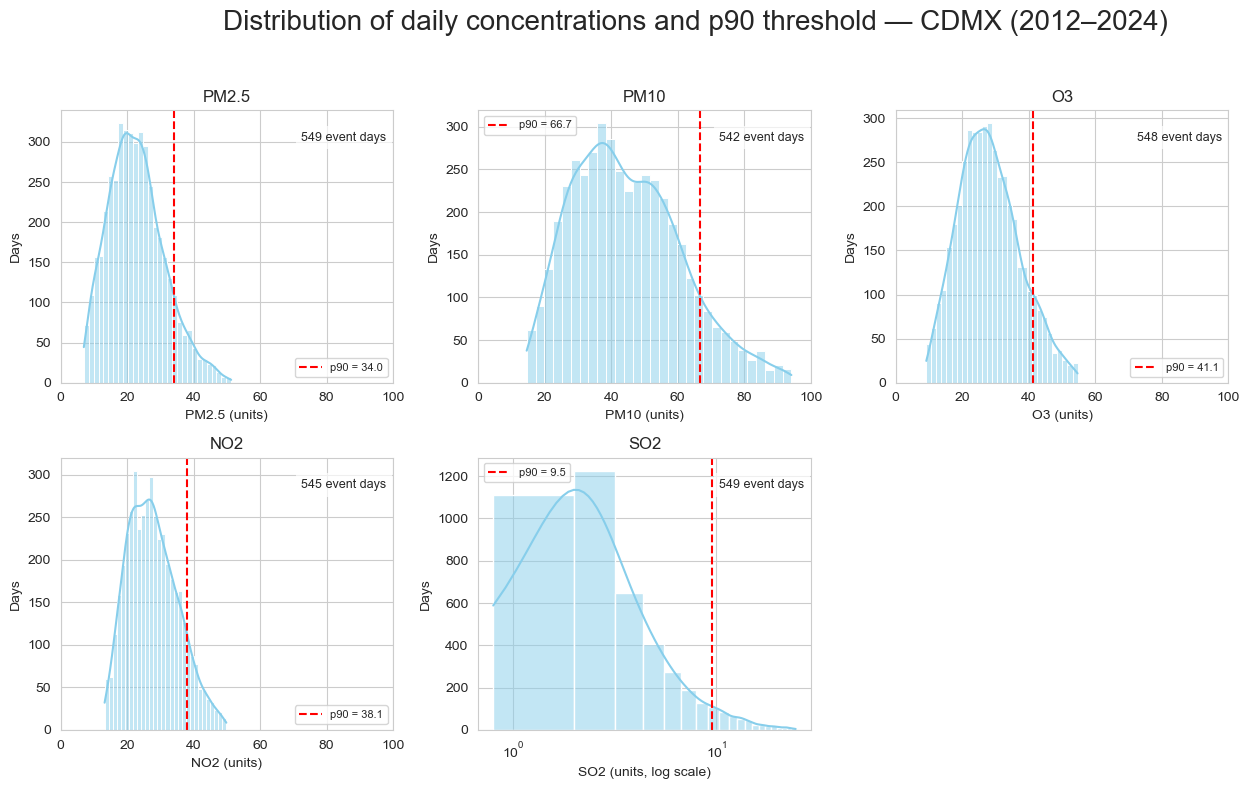

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

for i, p in enumerate(pollutants):
    ax = axes[i]
    x = city[p].dropna().values

    # soft clipping 1–99 percentile (avoids very long tails)
    x = x[(x >= np.percentile(x, 1)) & (x <= np.percentile(x, 99))]

    bins = 30 if p != "SO2" else 20
    sns.histplot(x, bins=bins, kde=True, ax=ax, color="skyblue")

    # 90th percentile and vertical line
    p90 = np.percentile(x, 90)
    ax.axvline(p90, color="red", linestyle="--", lw=1.5, label=f"p90 = {p90:.1f}")

    # number of event days (according to 'events' dictionary)
    ev_count = len(events[p])
    ax.text(0.98, 0.9, f"{ev_count} event days", transform=ax.transAxes,
            ha="right", va="center", fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, lw=0))

    # title and axes
    ax.set_title(p)
    ax.set_xlabel(f"{p} (units)")
    ax.set_ylabel("Days")
    ax.legend(fontsize=8)

    # only for SO₂, logarithmic axis
    if p == "SO2":
        ax.set_xscale('log')
        ax.set_xlabel("SO2 (units, log scale)")

    else:
        # uniform range for other pollutants
        ax.set_xlim(0, 100)
        
# deactivate the sixth empty subplot
axes[-1].axis('off')

# general title for the multipanel
fig.suptitle("Distribution of daily concentrations and p90 threshold — CDMX (2012–2024)",
             y=0.98, fontsize=20)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()
